In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm,solve_discrete_are, eigvals,sqrtm, inv, solve_discrete_lyapunov, pinv
from numba import njit
from typing import Tuple
from numpy.linalg import inv
from scipy.stats import chi2
import os 

# Importando todas as funções do filtro de Kalman
from utils import *


# Configuração de estilo para os gráficos ficarem mais legíveis
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Identificação de Covariâncias e Filtro de Kalman Adaptativo

### 1. O Problema
O Filtro de Kalman exige duas matrizes que, na prática, são desconhecidas:
* **$\mathbf{Q}$**: Incerteza do modelo matemático.
* **$\mathbf{R}$**: Incerteza dos sensores.

O grande desafio é a **identificabilidade**: como calcular $\mathbf{Q}$ e $\mathbf{R}$ de forma exata usando apenas os dados que o sistema consegue observar.

> **Referência Base:** *Zhang et al. (2020). "On the Identification of Noise Covariances and Adaptive Kalman Filtering: A New Look at a 50 Year-Old Problem."*

> DOI: 10.1109/ACCESS.2020.2982407
> 
### 2. A Solução Proposta
O artigo resolve o problema através de três pilares práticos:

1. **Critérios de Identificabilidade**: Define regras matemáticas para confirmar se é possível descobrir $\mathbf{Q}$ e $\mathbf{R}$ com os dados disponíveis.
2. **Algoritmo Adaptativo (6 etapas)**: Utiliza **Gradiente Descendente** para ajustar e otimizar o ganho de Kalman ($W$) repetidas vezes até chegar ao valor ideal.
3. **Nova Estimativa de $\mathbf{R}$**: Usa os erros já corrigidos (*resíduos post-fit*) para isolar o ruído real do sensor, garantindo que as matrizes geradas sejam fisicamente válidas.

### 3. Resultados Obtidos
* **Maior Precisão**: Erro (RMSE) significativamente menor quando comparado a métodos clássicos (como os de Mehra e Bélanger).
* **Alta Robustez**: O algoritmo mantém-se estável e converge mesmo em situações complexas onde os métodos tradicionais falham.adicionais falham.adicionais falham.adicionais falham.em

# 2. Implementação do Algoritmo (Abordagem em 6 Etapas)
### 1. Modelo de Espaço de Estados (Gauss‑Markov)

$$
\begin{aligned}
\mathbf{x}(k+1) &= \mathbf{F}\,\mathbf{x}(k) + \mathbf{\Gamma}\,\mathbf{v}(k) \quad & \text{(Dinâmica do estado)} \\[4pt]
\mathbf{z}(k) &= \mathbf{H}\,\mathbf{x}(k) + \mathbf{w}(k) \quad & \text{(Equação de medição)}
\end{aligned}
$$

| Símbolo | Dimensão | Descrição |
|---------|----------|-----------|
| $\mathbf{x}(k)$ | $n_x \times 1$ | Vetor de estado no instante $k$ |
| $\mathbf{z}(k)$ | $n_z \times 1$ | Vetor de medição |
| $\mathbf{F}$ | $n_x \times n_x$ | Matriz de transição de estado |
| $\mathbf{H}$ | $n_z \times n_x$ | Matriz de observação |
| $\mathbf{\Gamma}$ | $n_x \times n_v$ | Matriz de ganho do ruído de processo |
| $\mathbf{v}(k)$ | $n_v \times 1$ | Ruído de processo, branco, Gaussiano, $\mathbb{E}[\mathbf{v}(k)\mathbf{v}(k)^\top]=\mathbf{Q}$ |
| $\mathbf{w}(k)$ | $n_z \times 1$ | Ruído de medição, branco, Gaussiano, $\mathbb{E}[\mathbf{w}(k)\mathbf{w}(k)^\top]=\mathbf{R}$ |

**Hipóteses:**
- $\mathbf{v}(k)$, $\mathbf{w}(k)$ e $\mathbf{x}(0)$ são mutuamente independentes.
- $\mathbf{Q} \succ 0$, $\mathbf{R} \succ 0$.
- O par $(\mathbf{F},\mathbf{H})$ é observável e $(\mathbf{F},\mathbf{\Gamma}\mathbf{Q}^{1/âmetros livres em $R$ e $Q$.thcal{I}$ as colunas correspondentes aos elementos excluídos.matriz $\mathbf{Q}$.

### Condições de Identificabilidade de $Q$ e $R$ (resumo)

**1. Sistema de identificação**  
$$
\mathcal{I} \begin{bmatrix} \operatorname{vec}(Q) \\ \operatorname{vec}(R) \end{bmatrix} = \begin{bmatrix} L_0 \\ \vdots \\ L_m \end{bmatrix}
$$
- $\mathcal{I}$: matriz de identificabilidade  
- $L_j = \mathbb{E}[\xi(k)\xi(k-j)^\top]$  

**2. Matrizes auxiliares**  
$\bar{F} = F(I - WH)$  
Coeficientes do polinômio mínimo de $\bar{F}$: $\sum_{i=0}^m a_i \bar{F}^{m-i}=0$, $a_0=1$  
Para $l=1,\dots,m$:  
$$
\mathcal{B}_l = H\Big(\sum_{i=0}^{l-1} a_i \bar{F}^{l-i-1}\Big)\Gamma,\quad
\mathcal{G}_l = a_l I_{n_z} - H\Big(\sum_{i=0}^{l-1} a_i \bar{F}^{l-i-1}\Big)FW
$$
$\mathcal{G}_0 = I_{n_z}$  

**3. Construção de $\mathcal{I}$ (Algoritmo 1)**  
Para cada $j=0,\dots,m$:
- Para cada elemento único de $Q$ ($q_{lp}$ com $p\ge l$):  
  coluna $=$ $\operatorname{vec}\!\Big(\sum_{i=j+1}^m (\mathbf{b}_{i,l}\mathbf{b}_{i-j,p}^\top + \mathbf{b}_{i,p}\mathbf{b}_{i-j,l}^\top)\Big)$
- Para cada elemento único de $R$ ($r_{lp}$ com $p\ge l$):  
  coluna $=$ $\operatorname{vec}\!\Big(\sum_{i=j}^m (\mathbf{g}_{i,l}\mathbf{g}_{i-j,p}^\top + \mathbf{g}_{i,p}\mathbf{g}_{i-j,l}^\top)\Big)$

**4. Condição de posto**  
$$\operatorname{rank}(\mathcal{I}) - n_R \ge n_Q$$  

onde $n_R$, $n_Q$ são números de parâmetros livres em $R$ e $Q$.

In [3]:
#Geração da matriz de Identicabilidade:
def minimal_polynomial_coeffs(A, tol=1e-8):
    """
    Coeficientes do polinômio mínimo de A: [a0, a1, ..., am], com a0 = 1.
 
    Resolve: A^m + a1·A^{m-1} + ... + am·I = 0
    Rearranjando: [vec(A^{m-1}) | ... | vec(I)] · [a1; ...; am] = -vec(A^m)
    """
    n = A.shape[0]
    powers = [np.eye(n)]
    for _ in range(n):
        powers.append(powers[-1] @ A)
 
    vec_powers = [p.flatten('F') for p in powers]
 
    for m in range(1, n + 1):
        # Colunas na ordem decrescente de potência: A^{m-1}, ..., I
        cols  = [vec_powers[j] for j in range(m - 1, -1, -1)]
        X_ls  = np.column_stack(cols)
        y_ls  = -vec_powers[m]
        coeffs, _, _, _ = np.linalg.lstsq(X_ls, y_ls, rcond=None)
 
        # BUG-2: usar norma explícita em vez de residuals[0]
        if np.linalg.norm(X_ls @ coeffs - y_ls) < tol:
            full = np.zeros(m + 1)
            full[0]  = 1.0
            full[1:] = coeffs   # BUG-1: sem [::-1]
            return np.real(full)
 
    return np.real(np.poly(A))   # fallback: polinômio característico

def compute_B_G_matrices(F, H, Gamma, W):
    """
    Calcula as listas B_list (i=1..m) e G_list (i=0..m) conforme definido no artigo.
    
    B_l = H · S_l · Γ,  S_l = Σ_{i=0}^{l-1} a_i F̄^{l-i-1}
    G_l = a_l·I − H · S_l · F · W,  G_0 = I
    
    Parâmetros:
    -----------
    F : ndarray (n_x, n_x)
    H : ndarray (n_z, n_x)
    Gamma : ndarray (n_x, n_v)
    W : ndarray (n_x, n_z)  # ganho do filtro (pode ser subótimo ou inicial)
    
    Retorna:
    --------
    B_list : list de ndarrays (comprimento m), cada um (n_z, n_v)
    G_list : list de ndarrays (comprimento m+1), cada um (n_z, n_z)
    a_coeffs : ndarray (m+1,) coeficientes do polinômio mínimo
    m : int
    """
    n_x  = F.shape[0]
    I_nx = np.eye(n_x)
    I_nz = np.eye(H.shape[0])
    F_bar = F @ (I_nx - W @ H)
 
    a = minimal_polynomial_coeffs(F_bar)
    a = a / a[0]        # garante a0 = 1
    m = len(a) - 1
 
    Fb_pow = [I_nx]
    for _ in range(1, m):
        Fb_pow.append(Fb_pow[-1] @ F_bar)
 
    S = [None] * (m + 1)
    for l in range(1, m + 1):
        S[l] = sum(a[i] * Fb_pow[l - i - 1] for i in range(l))
 
    B_list = [H @ S[l] @ Gamma                             for l in range(1, m + 1)]
    G_list = [I_nz] + [a[l] * I_nz - H @ S[l] @ F @ W    for l in range(1, m + 1)]
 
    return B_list, G_list, a, m
    
def build_identifiability_matrix(B_list, G_list, m, n_v, n_z):
    """
    Constrói a matriz de identificabilidade de covariância de ruído F
    conforme Algorithm 1 do artigo.

    Parâmetros:
    -----------
    B_list : list of ndarray
        Lista de matrizes B_i (i = 1..m), cada uma de dimensão (n_z, n_v).
    G_list : list of ndarray
        Lista de matrizes G_i (i = 0..m), cada uma de dimensão (n_z, n_z).
    m : int
        Ordem do polinômio mínimo da matriz F_bar = F*(I - W*H).
    n_v : int
        Dimensão do ruído de processo v(k).
    n_z : int
        Dimensão da medição z(k).

    Retorna:
    --------
    F_mat : ndarray
        Matriz de identificabilidade com dimensão ((m+1)*n_z^2, n_cols),
        onde n_cols = n_v*(n_v+1)//2 + n_z*(n_z+1)//2.
    """
    n_cols = n_v * (n_v + 1) // 2 + n_z * (n_z + 1) // 2
    I_mat  = np.zeros(((m + 1) * n_z ** 2, n_cols))
 
    Bc = [[B_list[i-1][:, c] for c in range(n_v)] for i in range(1, m+1)]
    Gc = [[G_list[i][:, c]   for c in range(n_z)] for i in range(m+1)]
 
    for j in range(m + 1):
        r, k = j * n_z**2, 0
        z2 = n_z**2
 
        for l in range(1, n_v + 1):
            b = (sum(np.outer(Bc[i-1][l-1], Bc[i-j-1][l-1])
                     for i in range(j+1, m+1))
                 if j < m else np.zeros((n_z, n_z)))
            I_mat[r:r+z2, k] = b.flatten('F');  k += 1
            for p in range(l+1, n_v+1):
                d = (sum(np.outer(Bc[i-1][l-1], Bc[i-j-1][p-1])
                         + np.outer(Bc[i-1][p-1], Bc[i-j-1][l-1])
                         for i in range(j+1, m+1))
                     if j < m else np.zeros((n_z, n_z)))
                I_mat[r:r+z2, k] = d.flatten('F');  k += 1
 
        for l in range(1, n_z + 1):
            g = sum(np.outer(Gc[i][l-1], Gc[i-j][l-1]) for i in range(j, m+1))
            I_mat[r:r+z2, k] = g.flatten('F');  k += 1
            for p in range(l+1, n_z+1):
                e = sum(np.outer(Gc[i][l-1], Gc[i-j][p-1])
                        + np.outer(Gc[i][p-1], Gc[i-j][l-1])
                        for i in range(j, m+1))
                I_mat[r:r+z2, k] = e.flatten('F');  k += 1
 
    return I_mat

In [4]:
print("=== Exemplo do Artigo (Seção III, Eqs. 38-39) ===")

# Definição do sistema
F = np.array([[0.9, 0.0, 0.0],
              [1.0, 0.9, 0.0],
              [0.0, 0.0, 0.9]])
H = np.array([[1.0, 0.0, 0.0],
              [0.0, 0.0, 1.0]])
Gamma = np.eye(3)          # n_v = 3
W = np.zeros((3, 2))       # W = 0 para análise de identificabilidade

# Dimensões
n_x = 3
n_z = 2
n_v = 3

# Cálculo de B e G
B_list, G_list, a_coeffs, m = compute_B_G_matrices(F, H, Gamma, W)

print(f"\nGrau do polinômio mínimo (m): {m}")
print(f"Coeficientes a_i: {np.round(a_coeffs, 4)}")

# Construção da matriz de identificabilidade I
I_mat = build_identifiability_matrix(B_list, G_list, m, n_v, n_z)

print(f"\nDimensão da matriz I: {I_mat.shape}")
print(f"Posto de I: {np.linalg.matrix_rank(I_mat)}")

# Número de incógnitas
n_Q_full = n_v * (n_v + 1) // 2   # Q simétrica 3x3 -> 6 parâmetros
n_R_full = n_z * (n_z + 1) // 2   # R simétrica 2x2 -> 3 parâmetros
n_total = n_Q_full + n_R_full

print(f"\nParâmetros livres em Q (simétrica): {n_Q_full}")
print(f"Parâmetros livres em R (simétrica): {n_R_full}")
print(f"Total de incógnitas: {n_total}")

# Verificação da condição
rank_I = np.linalg.matrix_rank(I_mat)
if rank_I < n_total:
    print("\nConclusão: Q e R NÃO são identificáveis (posto < número de incógnitas).")
else:
    print("\nConclusão: Q e R SÃO identificáveis.")

# -----------------------------------------------------------------
# Agora supondo que Q é diagonal (3 parâmetros) e R é simétrica (3)
n_Q_diag = 3
n_R_sym = 3
n_total_diag = n_Q_diag + n_R_sym

# Para essa análise, precisamos remover as colunas de I correspondentes
# aos elementos cruzados de Q. As colunas de Q estão ordenadas:
# q11, q22, q33, q12, q13, q23 (ordem de vec para triangular superior)
# As primeiras n_v colunas são as diagonais, depois vêm os cruzados.
cols_to_keep = list(range(n_v))  # colunas diagonais de Q
cols_to_keep.extend(range(n_Q_full, n_Q_full + n_R_sym))  # todas colunas de R

I_diag = I_mat[:, cols_to_keep]
rank_diag = np.linalg.matrix_rank(I_diag)

print("\n--- Considerando Q diagonal ---")
print(f"Posto de I reduzida: {rank_diag}")
print(f"Total de incógnitas (Q diag + R sim): {n_total_diag}")
if rank_diag == n_total_diag:
    print("Conclusão: Com Q diagonal, o sistema É identificável.")
else:
    print("Conclusão: Mesmo com Q diagonal, o sistema NÃO é identificável.")

=== Exemplo do Artigo (Seção III, Eqs. 38-39) ===

Grau do polinômio mínimo (m): 2
Coeficientes a_i: [ 1.   -1.8   0.81]

Dimensão da matriz I: (12, 9)
Posto de I: 6

Parâmetros livres em Q (simétrica): 6
Parâmetros livres em R (simétrica): 3
Total de incógnitas: 9

Conclusão: Q e R NÃO são identificáveis (posto < número de incógnitas).

--- Considerando Q diagonal ---
Posto de I reduzida: 5
Total de incógnitas (Q diag + R sim): 6
Conclusão: Mesmo com Q diagonal, o sistema NÃO é identificável.


In [5]:
def check_noise_identifiability(F, H, Gamma, W=None, verbose=True):
    """
    Verifica a identificabilidade das matrizes de covariância Q e R
    para um sistema linear no espaço de estados.
    
    Parâmetros:
    -----------
    F : ndarray
        Matriz de transição de estados.
    H : ndarray
        Matriz de observação.
    Gamma : ndarray
        Matriz de acoplamento do ruído de processo.
    W : ndarray, opcional
        Ganho cruzado. Se None, será inicializado com zeros.
    verbose : bool
        Se True, imprime o relatório detalhado da análise no console.
        
    Retornos:
    ---------
    is_identifiable_full : bool
        True se o sistema for identificável considerando Q e R totalmente simétricas.
    is_identifiable_diag : bool
        True se o sistema for identificável considerando Q diagonal e R simétrica.
    I_mat : ndarray
        A matriz de identificabilidade construída.
    """
    # Inferir dimensões a partir das matrizes
    n_x = F.shape[0]
    n_z = H.shape[0]
    n_v = Gamma.shape[1]
    
    # Se W não for fornecido, assume 0 para análise de identificabilidade
    if W is None:
        W = np.zeros((n_x, n_z))
        
    if verbose:
        print("=== Análise de Identificabilidade das Matrizes de Ruído ===")
        
    # Cálculo de B e G (assume-se que a função já está definida no escopo global)
    B_list, G_list, a_coeffs, m = compute_B_G_matrices(F, H, Gamma, W)
    
    if verbose:
        print(f"\nGrau do polinômio mínimo (m): {m}")
        print(f"Coeficientes a_i: {np.round(a_coeffs, 4)}")
        
    # Construção da matriz de identificabilidade I
    I_mat = build_identifiability_matrix(B_list, G_list, m, n_v, n_z)
    rank_I = np.linalg.matrix_rank(I_mat)
    
    if verbose:
        print(f"\nDimensão da matriz I: {I_mat.shape}")
        print(f"Posto de I: {rank_I}")
        
    # Número de incógnitas (Matrizes Simétricas completas)
    n_Q_full = n_v * (n_v + 1) // 2   # Q simétrica
    n_R_full = n_z * (n_z + 1) // 2   # R simétrica
    n_total = n_Q_full + n_R_full
    
    # Verificação da condição para Q e R simétricas
    is_identifiable_full = bool(rank_I >= n_total)
    
    if verbose:
        print(f"\nParâmetros livres em Q (simétrica): {n_Q_full}")
        print(f"Parâmetros livres em R (simétrica): {n_R_full}")
        print(f"Total de incógnitas: {n_total}")
        if not is_identifiable_full:
            print("Conclusão: Q e R NÃO são identificáveis (posto < número de incógnitas).")
        else:
            print("Conclusão: Q e R SÃO identificáveis.")
            
    # -----------------------------------------------------------------
    # Análise supondo Q diagonal e R simétrica
    n_Q_diag = n_v
    n_R_sym = n_R_full
    n_total_diag = n_Q_diag + n_R_sym
    
    # Colunas correspondentes (assume que as primeiras n_v colunas são a diagonal de Q)
    cols_to_keep = list(range(n_v)) 
    cols_to_keep.extend(range(n_Q_full, n_Q_full + n_R_sym)) 
    
    I_diag = I_mat[:, cols_to_keep]
    rank_diag = np.linalg.matrix_rank(I_diag)
    
    is_identifiable_diag = bool(rank_diag >= n_total_diag)
    
    if verbose:
        print("\n--- Considerando Q diagonal ---")
        print(f"Posto de I reduzida: {rank_diag}")
        print(f"Total de incógnitas (Q diag + R sim): {n_total_diag}")
        if is_identifiable_diag:
            print("Conclusão: Com Q diagonal, o sistema É identificável.")
        else:
            print("Conclusão: Mesmo com Q diagonal, o sistema NÃO é identificável.")
            
    return is_identifiable_full, is_identifiable_diag, I_mat

def normalized_innovation_squared(nu, S):
    """NIS médio: E[ν(k)^T S^{-1} ν(k)]  (Eq. 191)."""
    S_inv = inv(S)
    return float(np.mean([n @ S_inv @ n for n in nu]))

if __name__ == "__main__":
    print("=== Exemplo do Artigo (Seção III, Eqs. 38-39) ===")
    
    F_ex = np.array([[0.9, 0.0, 0.0],
                     [1.0, 0.9, 0.0],
                     [0.0, 0.0, 0.9]])
    
    H_ex = np.array([[1.0, 0.0, 0.0],
                     [0.0, 0.0, 1.0]])
    
    Gamma_ex = np.eye(3)
    
    # Chamando a função recém-criada
    full_id, diag_id, I_matrix = check_noise_identifiability(F_ex, H_ex, Gamma_ex)

=== Exemplo do Artigo (Seção III, Eqs. 38-39) ===
=== Análise de Identificabilidade das Matrizes de Ruído ===

Grau do polinômio mínimo (m): 2
Coeficientes a_i: [ 1.   -1.8   0.81]

Dimensão da matriz I: (12, 9)
Posto de I: 6

Parâmetros livres em Q (simétrica): 6
Parâmetros livres em R (simétrica): 3
Total de incógnitas: 9
Conclusão: Q e R NÃO são identificáveis (posto < número de incógnitas).

--- Considerando Q diagonal ---
Posto de I reduzida: 5
Total de incógnitas (Q diag + R sim): 6
Conclusão: Mesmo com Q diagonal, o sistema NÃO é identificável.


### Inicialização:
Nessa etapa é obtido o ganho estabilizante inicial $\mathbf{W}^{(0)}$, resolvendo a equação de Riccati com estimativas grosseiras para $\mathbf{Q}$ e $\mathbf{R}$, garantindo que o filtro seja estável.

1. Escolha um $\mathbf{Q}_0$ e $\mathbf{R}_0$ inicial, que sejam positivos e semidefinidos compatível com a escala das medições; usar identidades funciona bem a priori.

2. Resolver a Equação Algébrica de Riccati Discreta (DARE):
   $$
   \bar{\mathbf{P}} = \mathbf{F}\bar{\mathbf{P}}\mathbf{F}^\top - \mathbf{F}\bar{\mathbf{P}}\mathbf{H}^\top \left( \mathbf{H}\bar{\mathbf{P}}\mathbf{H}^\top + \mathbf{R}_0 \right)^{-1} \mathbf{H}\bar{\mathbf{P}}\mathbf{F}^\top + \mathbf{\Gamma}\mathbf{Q}_0\mathbf{\Gamma}^\top
   $$

3. Calcular o Ganho de Kalman Correspondente:
   $$
   \mathbf{W}^{(0)} = \bar{\mathbf{P}}\mathbf{H}^\top \left( \mathbf{H}\bar{\mathbf{P}}\mathbf{H}^\top + \mathbf{R}_0 \right)^{-1}
   $$

4. Verificar a estabilidade (garantir que os autovalores da matriz de malha fechada são estáveis), caso contrário escolher outros $\mathbf{Q}_0$ e $\mathbf{R}_0$:
   $$
   \bar{\mathbf{F}} = \mathbf{F}\left(\mathbf{I} - \mathbf{W}^{(0)}\mathbf{H}\right), \qquad |\lambda(\bar{\mathbf{F}})| < 1
   $$

In [6]:
def init_gain_W(F,H,Gamma, Q0=None, R0=None):
    """
    Calcula um ganho de Kalman estabilizante inicial.
    
    X[k+1] = F @ X[k] + Gamma @ V[k] 
    Z[k]   = H @ X[k] + w[k] 
    
    Parâmetros:
    F, H, Gamma : Matrizes do Sistema (Já discretizadas)
    Q0, R0      : Estimativas iniciais das covariâncias 

    Retorna:
    W0: Ganho de Kalman estabilizante 
    """
    nx, nz, nv = F.shape[0], H.shape[0], Gamma.shape[1]
    Q0 = np.eye(nv) if Q0 is None else Q0
    R0 = np.eye(nz) if R0 is None else R0
 
    Q_eff = Gamma @ Q0 @ Gamma.T
    P_bar = solve_discrete_are(F.T, H.T, Q_eff, R0)
    S     = H @ P_bar @ H.T + R0
    W0    = P_bar @ H.T @ inv(S)
 
    if np.max(np.abs(eigvals(F @ (np.eye(nx) - W0 @ H)))) >= 1.0:
        print("Aviso: ganho inicial não estabilizante.")
    return W0

In [7]:
## Exemplo de uso:
# Sistema exemplo
F = np.array([[0.9, 1.0],
              [0.0, 0.9]])
H = np.array([[1.0, 0.0]])
Gamma = np.eye(2)

W_init, _ = init_gain_W(F, H, Gamma)
print("W inicial:\n", W_init)

W inicial:
 [0.80092127]


### Passo 1: Gerar sequência de inovação e pós-ajuste

Executa o filtro de Kalman com o ganho estabilizante $\mathbf{W}$ sobre todos os dados, gerando as sequências de inovação $\boldsymbol{\nu}(k)$ e resíduo pós-ajuste $\boldsymbol{\mu}(k)$.

**Predição:**
$$
\hat{\mathbf{x}}(k+1|k) = \mathbf{F}\,\hat{\mathbf{x}}(k|k)
$$

**Inovação:**
$$
\boldsymbol{\nu}(k+1) = \mathbf{z}(k+1) - \mathbf{H}\,\hat{\mathbf{x}}(k+1|k)
$$

**Atualização:**
$$
\hat{\mathbf{x}}(k+1|k+1) = \hat{\mathbf{x}}(k+1|k) + \mathbf{W}\,\boldsymbol{\nu}(k+1)
$$

**Resíduo pós-ajuste:**
$$
\boldsymbol{\mu}(k+1) = \mathbf{z}(k+1) - \mathbf{H}\,\hat{\mathbf{x}}(k+1|k+1)
$$

A ideia principal é que se $\mathbf{W}$ for o ganho ótimo de Kalman, $\boldsymbol{\nu}(k)$ será um ruído branco.

In [8]:
def generate_residuals(Z: np.ndarray, 
                       F: np.ndarray, 
                       H: np.ndarray, 
                       W: np.ndarray, 
                       x0_hat: np.ndarray = None):
    """
    Roda um Filtro de Kalman estacionário sobre os dados para gerar resíduos.
    
    Z : Array de medições com shape (N, nz) onde N é o número de amostras
    F, H : Matrizes do sistema
    W : Ganho de Kalman estabilizante
    x0_hat : Estimativa do estado inicial. Se None, assume zero.
    
    Retorna:
    v : Sequência de inovação (N, nz)
    mu : Sequência de resíduos pós-ajuste (N, nz)
    """
    N, nz  = Z.shape
    nx     = F.shape[0]
    nu     = np.zeros((N, nz))
    mu     = np.zeros((N, nz))
    x_hat  = np.zeros((nx, 1)) if x0_hat is None else x0_hat.reshape(nx, 1)
 
    for k in range(N):
        z_k   = Z[k].reshape(nz, 1)
        nu_k  = z_k - H @ x_hat
        x_upd = x_hat + W @ nu_k
        mu_k  = z_k - H @ x_upd
        nu[k] = nu_k.flatten()
        mu[k] = mu_k.flatten()
        x_hat = F @ x_upd
    return nu, mu

### Passo 2: Cálculo das Autocovariâncias
* A partir das inovações obtidas, calcula-se a autocovariância amostral $\hat{C}_j$ para diferentes atrasos (*lags*) $j = 0, 1, \dots, N_c$.
* Estas autocovariâncias capturam a assinatura estatística dos erros atuais do modelo.

**Definição (Eq. 50):**  
Para uma sequência de inovações $\{\boldsymbol{\nu}(k)\}_{k=1}^N$, a matriz de autocovariância amostral no lag $i$ é:

$$
\hat{\mathbf{C}}(i) = \frac{1}{N-M} \sum_{j=1}^{N-M} \boldsymbol{\nu}(j)\,\boldsymbol{\nu}(j+i)^\top, \qquad i = 0, 1, \dots, M-1
$$

onde $M$ é o número máximo de lags considerado (tipicamente $M \ge n_x$).

In [9]:
def compute_autocovariance(nu, M):
    """
    Ĉ(i) = 1/(N-M) · Σ_{j=1}^{N-M} ν(j+i) ν(j)^T,  i = 0 … M-1.
 
    BUG-4: divisor unificado N-M para todos os lags (conforme Eq. 50).
    """
    N, nz  = nu.shape
    denom  = max(N - M, 1)
    C      = np.zeros((M, nz, nz))
    for i in range(M):
        C[i] = nu[i: N - M + i].T @ nu[: N - M] / denom
    return C

### Passo 3: Otimização do Ganho ($\mathbf{W}$) via Gradiente Descendente

O objetivo é atualizar o ganho $\mathbf{W}$ de modo que a sequência de inovações $\boldsymbol{\nu}(k)$ seja descorrelacionada (ruído branco).

#### Função Objetivo (Eq. 52)

$$
J(\mathbf{W}) = \frac{1}{2} \operatorname{tr} \left\{ \sum_{i=1}^{M-1} \mathbf{E}\, \hat{\mathbf{C}}(i)^\top \mathbf{E}^2 \, \hat{\mathbf{C}}(i)\, \mathbf{E} \right\}\tag{52}
$$

onde:
- $\hat{\mathbf{C}}(i) = \frac{1}{N-i}\sum_{k=1}^{N-i} \boldsymbol{\nu}(k+i)\boldsymbol{\nu}(k)^\top$ (covariância amostral das inovações, lag $i$)
- $\mathbf{E} = \big[ \operatorname{diag}(\hat{\mathbf{C}}(0)) \big]^{-1/2}$ (matriz de normalização)
- $M \ge n_x$ (número de lags considerado)n$\end{align}




O autor também apresenta outra forma de calcular a função objetivo, dada em (54)

$$
    J = \frac{1}{2} \mathrm{tr} \left\{ \sum_{i=1}^{M-1} \Theta(i) X \mathscr{E}^2 X' \right\} \tag{54}
$$

Onde:

- $\Theta(i) = \Phi(i)' \mathscr{E}^2 \Phi(i)$
- $\Phi(i) = H \bar{F}^{i-1} F$
- $X = \Psi - W C(0) $ 
- $\Psi = \bar{P} H'$
- $\mathbf{E} = \left[ \mathbf{diag}(C(0)) \right]^{-\frac{1}{2}} $

#### Gradiente de $J$ em relação a $\mathbf{W}$ (Eq. 60)

$$
\nabla_W J = \sum_{i=1}^{M-1} \mathbf{\Phi}(i)^\top \mathbf{E}^2 \hat{\mathbf{C}}(i) \mathbf{E}^2 \hat{\mathbf{C}}(0) \;+\; \mathbf{F}^\top \mathbf{Z} \mathbf{F} \mathbf{X} \;-\; \sum_{i=1}^{M-1} \sum_{\ell=0}^{i-2} \left[ \hat{\mathbf{C}}(\ell+1) \mathbf{E}^2 \hat{\mathbf{C}}(i)^\top \mathbf{E}^2 \mathbf{H} \bar{\mathbf{F}}^{i-\ell-2} \right]^\top \tag{60}
$$

- $\bar{\mathbf{F}}= \mathbf{F}(\mathbf{I} - \mathbf{W}\mathbf{H})$
 (matriz de malha fechada)
- $\mathbf{\Phi}(i) = \mathbf{H} \bar{\mathbf{F}}^{\,i-1} \mathbf{F}$
- $\mathbf{Z}$ é solução da equação de Lyapunov discreta (Eq. 61):


$$\mathbf{Z} = \bar{\mathbf{F}}^\top \mathbf{Z} \bar{\mathbf{F}} + \frac{1}{2}\sum_{i=1}^{M-1} \Big[ \left[\mathbf{\Phi}(i)^\top \mathbf{E}^2 \hat{\mathbf{C}}(i) \mathbf{E}^2 \mathbf{H} \right]+ \left[\mathbf{\Phi}(i)^\top \mathbf{E}^2 \hat{\mathbf{C}}(i) \mathbf{E}^2 \mathbf{H} \right]^T \Big]\tag{61}$$ 

- $\mathbf{X} = \mathbf{\Psi} - \mathbf{W}\hat{\mathbf{C}}(0)$, onde $\mathbf{\Psi} = \bar{\mathbf{P}}\mathbf{H}^\top$  

  $\mathbf{X}$ pode ser obtido pela relação:
$$X = \begin{bmatrix} 
HF \\ 
H\bar{F}F \\ 
\vdots \\ 
H\bar{F}^{M-1}F 
\end{bmatrix}^{\dagger} 
\begin{bmatrix} 
\hat{C}(1) \\ 
\hat{C}(2) \\ 
\vdots \\ 
\hat{C}(M - 1) 
\end{bmatrix}$$

Onde:

$$
    \mathbf{A}^{\dagger} = (\mathbf{A}^T.\mathbf{A})^{-1}\mathbf{A}^T
$$


In [10]:
#Definindo função objetivo
def objective_J(W, F, H, C):
    """
    Calcula a função objetivo J(W) para o problema de identificação do ganho
    ótimo de Kalman, conforme a Equação (54) do artigo.

    J(W) = 1/2 * tr{ Σ_{i=1}^{M-1} Θ(i) · X · Θ² · Xᵀ }

    onde:
      - Θ(i) = Φ(i)ᵀ Θ² Φ(i)
      - Φ(i) = H · F̄^{i-1} · F
      - E² = [diag(Ĉ(0))]^{-1}  (normalização das covariâncias)
      - X é a solução do sistema linear dado por (62)

    Esta função quantifica a correlação residual das inovações; o valor ótimo
    de W é aquele que minimiza J(W), idealmente tendendo a zero para N → ∞.

    Parâmetros
    ----------
    W : ndarray, shape (nx, nz)
        Ganho estacionário do filtro de Kalman (variável de otimização).
    F : ndarray, shape (nx, nx)
        Matriz de transição de estado do sistema.
    H : ndarray, shape (nz, nx)
        Matriz de observação do sistema.
    C : list of ndarray, length M
        Lista das autocovariâncias amostrais das inovações.
        C[0] é a covariância contemporânea Ĉ(0), C[i] = Ĉ(i), i = 0,...,M-1.

    Retorna
    -------
    J : float
        Valor da função objetivo avaliada em W.
    """
    M = len(C)
    nz, nx = H.shape
    I_nx = np.eye(nx)
    C0 = C[0]
    E2 = np.diag(1.0 / np.maximum(np.diag(C0), 1e-12))
    F_bar = F @ (I_nx - W @ H)
    X = compute_X(F_bar, F, H, C, M)

    J = 0.0
    for i in range(1, M):
        Phi_i = H @ np.linalg.matrix_power(F_bar, i - 1) @ F
        Theta_i = Phi_i.T @ E2 @ Phi_i
        J += np.trace(Theta_i @ X @ E2 @ X.T)
    return 0.5 * J


def lstsq_reg(A, B, reg=1e-6):
    """
    Resolve o problema de mínimos quadrados linear com regularização de
    Tikhonov (ridge regression):

        min ||A X - B||_F^2 + reg * ||X||_F^2

    cuja solução é X = (Aᵀ A + reg·I)^{-1} Aᵀ B.

    Pode ser utilizada como alternativa à pseudoinversa para melhorar o
    condicionamento numérico quando A é mal condicionada.

    Parâmetros
    ----------
    A : ndarray, shape (m, n)
        Matriz de coeficientes.
    B : ndarray, shape (m, k)
        Matriz de termos independentes.
    reg : float, opcional (padrão=1e-6)
        Parâmetro de regularização.

    Retorna
    -------
    X : ndarray, shape (n, k)
        Solução regularizada de mínimos quadrados.
    """
    return np.linalg.solve(A.T @ A + reg * np.eye(A.shape[1]), A.T @ B)

# Cálculo do X via pseudo-inversa
def compute_X(F_bar, F, H, C, M):
    """
    Estima a matriz X = P̄ Hᵀ - W C(0) resolvendo o sistema linear (62) do artigo.

    A partir das inovações de um filtro subótimo, a matriz X satisfaz a relação:
        [ H F ]           [ Ĉ(1)   ]
        [ H F̄ F ]         [ Ĉ(2)   ]
        [   ...   ] · X = [   ...  ]
        [ H F̄^{M-1} F ]   [ Ĉ(M-1) ]

    O sistema é resolvido via mínimos quadrados (pseudoinversa), pois tipicamente
    é sobredeterminado (M ≥ nx).

    Parâmetros
    ----------
    F_bar : ndarray, shape (nx, nx)
        Matriz de transição de malha fechada: F̄ = F (I - W H).
    F : ndarray, shape (nx, nx)
        Matriz de transição de estado do sistema.
    H : ndarray, shape (nz, nx)
        Matriz de observação.
    C : list of ndarray, length M
        Autocovariâncias amostrais das inovações.
    M : int
        Número total de defasagens (lags) utilizadas.

    Retorna
    -------
    X : ndarray, shape (nx, nz)
        Matriz estimada que combina a covariância de predição e o ganho.
    """
    nz, nx = H.shape
    A_blocks = [H @ np.linalg.matrix_power(F_bar, i-1) @ F for i in range(1, M)]
    A = np.vstack(A_blocks)                     # ((M-1)*nz, nx)
    b = np.vstack([C[i] for i in range(1, M)])  # ((M-1)*nz, nz)

    # Resolver com regularização (ridge regression)
    X = lstsq_reg(A, b, reg=1e-6)                # usa (AᵀA + reg·I)⁻¹ Aᵀ b
    return X.reshape(nx, nz)

# Calculo de Z via Lyapunov
def compute_Z(F_bar, Phi, E2, H, C, M):
    """
    Resolve a equação de Lyapunov discreta (61) para obter a matriz Z,
    necessária no cálculo do gradiente da função objetivo.

    A matriz Z satisfaz:
        Z = F̄ᵀ Z F̄ + Q_Z

    onde o termo constante Q_Z é dado por:
        Q_Z = 1/2 Σ_{i=1}^{M-1} [ Φ(i)ᵀ Θ² Ĉ(i) Θ² H + (Φ(i)ᵀ Θ² Ĉ(i) Θ² H)ᵀ ]

    com Θ² = diag(Ĉ(0))^{-1} e Φ(i) = H F̄^{i-1} F.

    Parâmetros
    ----------
    F_bar : ndarray, shape (nx, nx)
        Matriz de transição de malha fechada.
    Phi : list of ndarray, length M-1
        Lista pré‑calculada das matrizes Φ(i), i=1,...,M-1.
    E2 : ndarray, shape (nz, nz)
        Matriz de normalização Θ² = diag(Ĉ(0))^{-1}.
    H : ndarray, shape (nz, nx)
        Matriz de observação.
    C : list of ndarray, length M
        Autocovariâncias amostrais das inovações.
    M : int
        Número total de defasagens.

    Retorna
    -------
    Z : ndarray, shape (nx, nx)
        Solução da equação de Lyapunov discreta.
    """
    nx = F_bar.shape[0]
    Q_Z = np.zeros((nx, nx))
    for i in range(1, M):
        # Phi[i-1] corresponde a Φ(i)
        term = Phi[i-1].T @ E2 @ C[i] @ E2 @ H
        Q_Z += 0.5 * (term + term.T)
    Z = solve_discrete_lyapunov(F_bar.T, Q_Z)
    return Z

def gradient_fd(W, F, H, C, eps=1e-7):
    """
    ∂J/∂W calculado por diferenças finitas centradas.
    """
    nx, nz = F.shape[0], H.shape[0]
    grad   = np.zeros((nx, nz))
    for a in range(nx):
        for b in range(nz):
            Wp = W.copy(); Wp[a, b] += eps
            Wm = W.copy(); Wm[a, b] -= eps
            grad[a, b] = (objective_J(Wp, F, H, C) - objective_J(Wm, F, H, C)) / (2 * eps)
    return grad
    
# Implementando função gradiente da função objetivo
def gradient_J(W, F, H, C):
    """
    Calcula o gradiente de J em relação a W.

        Parâmetros
    ----------
    W : numpy.ndarray, shape (nx, nz)
        Ganho estacionário do filtro de Kalman (a variável de otimização).
        nx = dimensão do estado, nz = dimensão da medição.

    F : numpy.ndarray, shape (nx, nx)
        Matriz de transição de estado do sistema (conhecida e fixa).

    H : numpy.ndarray, shape (nz, nx)
        Matriz de observação (conhecida e fixa).

    C : list of numpy.ndarray, length M
        Lista de matrizes de autocovariância amostral das inovações.
        C[i] tem shape (nz, nz) e representa Ĉ(i), i = 0, 1, ..., M-1.
        C[0] é a covariância contemporânea (lag 0).

    Retorna
    -------
    Grad : float
        Valor do gradiente da função objetivo .
        
    """
    M = len(C)
    nz, nx = H.shape
    I_nx = np.eye(nx)
    C0 = C[0]

    # Normalização E^2 = diag(C0)^{-1}
    diag_C0 = np.diag(C0)
    diag_C0 = np.maximum(diag_C0, 1e-12)
    E2 = np.diag(1.0 / diag_C0)

    # Matriz de malha fechada
    F_bar = F @ (I_nx - W @ H)

    # Pré‑calcular Phi(i) = H * F_bar^{i-1} * F  para i = 1 .. M-1
    Phi = []
    for i in range(1, M):
        Phi.append(H @ np.linalg.matrix_power(F_bar, i-1) @ F)

    # Calcular X e Z
    X = compute_X(F_bar, F, H, C, M)
    Z = compute_Z(F_bar, Phi, E2, H, C, M=M)
    # Inicializar gradiente (nx, nz)
    grad = np.zeros((nx, nz))

    # Somatório principal
    for i in range(1, M):
        # Primeiro termo: Phi(i)^T * E^2 * C(i) * E^2 * C(0)
        term1 = Phi[i-1].T @ E2 @ C[i] @ E2 @ C0
        grad -= term1

        # Segundo termo (soma dupla): l = 0 .. i-2
        for l in range(i-1):
            # [ C(l+1) * E^2 * C(i)^T * E^2 * H * F_bar^{i-l-2} ]^T
            C_l1 = C[l+1]                         # C(ℓ+1)
            power = i - l - 2
            F_pow = np.linalg.matrix_power(F_bar, power)
            inside = C_l1 @ E2 @ C[i].T @ E2 @ H @ F_pow   # (nz, nx)
            term2 = inside.T                      # (nx, nz)
            grad -= term2

        # ---------- Terceiro termo: - F^T Z_i F X (dentro do colchete) ----------
        # - ( - F^T Z_i F X ) = + F^T Z_i F X
        grad -= F.T @ Z @ F @ X

    return grad
    
# Método para garantir que F_bar é estável (F de malha fechada)
def is_stable(F_bar):
    """
    Verifica se a matriz de transição de malha fechada F̄ = F (I - W H)
    é assintoticamente estável (todos os autovalores têm magnitude estritamente
    menor que 1).

    A estabilidade de F̄ é uma condição necessária para a convergência do
    filtro de Kalman e para a validade das expressões de correlação utilizadas
    no método de identificação.

    Parâmetros
    ----------
    F_bar : ndarray, shape (nx, nx)
        Matriz de transição de malha fechada.

    Retorna
    -------
    stable : bool
        True se max|λ(F̄)| < 1, False caso contrário.
    """
    return np.max(np.abs(np.linalg.eigvals(F_bar))) < 1.0



  
#### Atualização do Ganho (Eq. 135)

$$
\mathbf{W}^{(r+1)} = \mathbf{W}^{(r)} - \alpha^{(r)} \nabla_{\mathbf{W}} J\big(\mathbf{W}^{(r)}\big) \tag{135}
$$

#### Passo Adaptativo – *Bold Driver* (Eq. 137)

O passo $\alpha^{(r)}$ é ajustado dinamicamente a cada iteração:

$$
\alpha^{(r)} = \begin{cases}
0.5\,\alpha^{(r-1)}, & \text{se } J^{(r)} > J^{(r-1)} \\[4pt]
\max\big(1.1\,\alpha^{(r-1)},\; \bar{c}\big), & \text{caso contrário}
\end{cases} \tag{137}
$$

com $\bar{c} = \min\!\Big( (N/N_s)^\beta,\; c_{\max} \Big)$ limitando o passo máximo.

#### Critérios de Parada

- $\|\mathbf{W}^{(r+1)} - \mathbf{W}^{(r)}\| < \zeta_W$  
- $\|\nabla_{\mathbf{W}} J\| < \zeta_\Delta$  
- $J < \zeta_J$  
- Paciência (estagnação de $J$ por várias iterações)  
- Número máximo de iterações $n_L$

#### Gradiente Numérico via Diferenças Finitas Centradas (`gradient_fd`)

$$
[\nabla_{\mathbf{W}} J]_{i,j} \approx \frac{J(\mathbf{W} + \epsilon \mathbf{E}_{i,j}) - J(\mathbf{W} - \epsilon \mathbf{E}_{i,j})}{2\epsilon}
$$

- $[\nabla_{\mathbf{W}} J]_{i,j}$ é o elemento da linha $i$ e coluna $j$ da matriz gradiente.
- $\mathbf{E}_{i,j}$ é uma matriz de zeros, contendo o valor $1$ apenas na posição $(i,j)$.
- $\epsilon$ (`eps`) é o passo de perturbação (um valor escalar muito pequeno, geralmente $10^{-5}$).

**Contras do método e do uso do $\epsilon$:**

- **Custo Computacional Alto:** A função de custo $J$ precisa ser calculada $2 \times n_x \times n_z$ vezes para formar uma única matriz gradiente. Torna-se impraticável para sistemas grandes.
- **Sensibilidade do $\epsilon$:** - Se $\epsilon$ for **muito grande**: A diferença finita não reflete a tangente real da curva, gerando um erro grosseiro de aproximação (erro de truncamento).
  - Se $\epsilon$ for **muito pequeno**: A precisão de ponto flutuante do computador falha ao subtrair números quase idênticos, resultando em ruído em vez de um gradiente válido (cancelamento catastrófico).

In [11]:
def update_gain_W(F, H, C, W_init, N, N_s=None, beta=2.0,
                  max_iter=100, tol_W=1e-6, tol_grad=1e-6, tol_J=1e-6,
                  patience=5, c=0.01, c_max=0.2, grad_eps=1e-5, approx=True):
    """
    Otimiza o ganho W via gradiente descendente com passo adaptativo (bold driver).

    Parâmetros
    ----------
    F : ndarray (nx, nx)
        Matriz de transição de estado.
    H : ndarray (nz, nx)
        Matriz de observação.
    C : list de ndarrays (M, nz, nz)
        Autocovariâncias amostrais das inovações (C[i] = lag i).
    W_init : ndarray (nx, nz)
        Ganho inicial estabilizante.
    N : int
        Número total de amostras observadas (usado para inicializar alpha).
    N_s : int, opcional
        Hiperparâmetro de escala para alpha. Se None, será usado N_s = N.
    beta : float, opcional
        Expoente para ajuste de alpha (padrão 2, conforme artigo).
    max_iter : int
        Máximo de iterações.
    tol : float
        Tolerância para convergência (gradiente e variação de W).
    patience : int
        Iterações sem melhora para parada antecipada.

    Retorna
    -------
    best_W : ndarray (nx, nz)
        Ganho com menor J observado.
    best_J : float
        Valor de J correspondente.
    """
    nx  = F.shape[0]
    I_nx = np.eye(nx)
    if N_s is None:
        N_s = N
 
    alpha  = min(c * (N / N_s) ** beta, c)   # Eq. 136
    c_bar  = min((N / N_s) ** beta, c_max)    # Eq. 138
 
    W       = W_init.copy()
    best_W  = W.copy()
    best_J  = objective_J(W, F, H, C)         
    J_prev  = best_J
    no_improve = 0
 
    for it in range(max_iter):
        if approx:
            grad = gradient_fd(W, F, H, C, eps=grad_eps)   
        else:
            grad = gradient_J(W,F,H,C)
        W_new   = W - alpha * grad
        F_bar_n = F @ (I_nx - W_new @ H)
 
        if not is_stable(F_bar_n):
            alpha *= 0.5
            no_improve += 1
            if no_improve >= patience:
                break
            continue
 
        J_new = objective_J(W_new, F, H, C)    
 
        # Bold driver (Eq. 137)
        alpha = 0.5 * alpha if J_new > J_prev else min(1.1 * alpha, c_bar)
 
        W      = W_new
        J_prev = J_new
 
        if J_new < best_J:
            best_J = J_new
            best_W = W.copy()
            no_improve = 0
        else:
            no_improve += 1
 
        # Condições de parada 1-5 (Seção VIII-C1)
        dW = np.linalg.norm(W - W_init) / (np.linalg.norm(W_init) + 1e-12)
        if dW < tol_W:           break   # Cond. 1
        if np.linalg.norm(grad) < tol_grad:  break   # Cond. 2
        if J_new < tol_J:        break   # Cond. 3
        if no_improve >= patience: break # Cond. 4
        # Cond. 5: max_iter já controla o loop
 
    return best_W, best_J


def step3_update_W(v, F, H, W_current, M_lags, max_iter=100, tol=1e-12,
                   N_s=None, beta=2.0):
    """
    Executa o passo 3 completo:
    - Calcula autocovariâncias de v
    - Otimiza W via gradiente adaptativo

    Parâmetros adicionais
    ---------------------
    N_s, beta : parâmetros para inicialização do passo alpha (Eq. 136)
    """
    N = v.shape[0]
    C = compute_autocovariance(v, M_lags)
    W_opt, J_opt = update_gain_W(F, H, C, W_current, N=N, N_s=N_s, beta=beta,
                                 max_iter=max_iter, tol_W=tol, tol_grad=tol, tol_J=tol)
    return W_opt, J_opt



### Passo 4: Estimação do Ruído de Medição ($\mathbf{R}$)
* Com o ganho $\mathbf{W}$ atualizado, calculam-se os **resíduos *post-fit***: 
  $$\mu(k) = \tilde{z}_{k|k} = \mathbf{z_k} - \mathbf{H}\hat{x}_{k|k}$$

  $$\mu(k) = (\mathbf{I}_{nz} - \mathbf{H}.\mathbf{W})\nu(k)$$

  
* A covariância $\mathbf{R}$ é estimada isolando a variância destes resíduos. O algoritmo aplica projeções matemáticas para garantir que $\mathbf{R}$ se mantenha **simétrica e definida positiva** (uma restrição física rigorosa).

O artigo provê 5 formas de estimar R, contudo, cada modo tem uma necessidade específica, d
| Método | Equação | Requisitos |
|--------|---------|------------|
| **R1** | $\mathbf{R} = (\mathbf{I}_{n_z} - \mathbf{H}\mathbf{W})\mathbf{S}$ | $\mathbf{S}$ e $\mathbf{W}$ |
| **R2** | $\mathbf{R} = \frac{1}{2}\Big(\mathbb{E}[\boldsymbol{\mu}\boldsymbol{\nu}^\top] + \mathbb{E}[\boldsymbol{\nu}\boldsymbol{\mu}^\top]\Big)$ | $\boldsymbol{\mu}$, $\boldsymbol{\nu}$ (sequências) |
| **R3** | $\mathbf{G} = \mathbf{R}\mathbf{S}^{-1}\mathbf{R}$  *(resolve-se como equação de Riccati contínua)* | $\mathbf{S}$, $\mathbf{G}$ |
| **R4** | $\mathbf{R} = \frac{1}{2}\big(\mathbf{G} + \mathbf{S} - \mathbf{H}\mathbf{W}\mathbf{S}\mathbf{W}^\top\mathbf{H}^\top\big)$ | $\mathbf{S}$, $\mathbf{G}$, $\mathbf{W}$, $\mathbf{H}$ |
| **R5** | $\mathbf{R} = \frac{1}{2}\Big(\mathbf{G}(\mathbf{I} - \mathbf{W}^\top\mathbf{H}^\top)^{-1} + (\mathbf{I} - \mathbf{H}\mathbf{W})^{-1}\mathbf{G}\Big)$ | $\mathbf{G}$, $\mathbf{W}$, $\mathbf{H}$ |

> **Recomendação do artigo:** O método **R3** é preferido porque garante automaticamente que $\mathbf{R}$ seja simétrica e definida positiva, além de ser numericamente mais estável. Para $\mathbf{R}$ diagonal, basta extrair a diagonal da solução.adas abaixo:

In [12]:
# Definindo função para estimar R
def estimate_R(nu=None, mu=None, S=None, G=None, H=None, W=None, method='R3'):
    """
    Estima a matriz de covariância de medição R usando um dos cinco métodos do artigo.

    Parâmetros
    ----------
    nu : ndarray (N, nz), opcional
        Sequência de inovações.
    mu : ndarray (N, nz), opcional
        Sequência de resíduos pós-ajuste.
    S : ndarray (nz, nz), opcional
        Covariância amostral das inovações (se já calculada).
    G : ndarray (nz, nz), opcional
        Covariância amostral dos resíduos pós-ajuste (se já calculada).
    H : ndarray (nz, nx)
        Matriz de observação.
    W : ndarray (nx, nz)
        Ganho estacionário do filtro.
    method : str, opcional ('R1', 'R2', 'R3', 'R4', 'R5')
        Método de estimação. Padrão: 'R3' (recomendado).

    Retorna
    -------
    R : ndarray (nz, nz)
        Estimativa da covariância do ruído de medição.
    """
    if S is None and nu is not None:
        S = nu.T @ nu / len(nu)
    if G is None and mu is not None:
        G = mu.T @ mu / len(mu)
 
    I_nz = np.eye(H.shape[0])
 
    if method == 'R1':
        R = (I_nz - H @ W) @ S
    elif method == 'R2':
        if nu is None or mu is None:
            raise ValueError("R2 requer nu e mu.")
        cross = mu.T @ nu / len(nu)
        R = 0.5 * (cross + cross.T)
    elif method == 'R3':
        S_sqrt     = sqrtm(S)
        S_inv_sqrt = inv(S_sqrt)
        R = S_sqrt @ sqrtm(S_inv_sqrt @ G @ S_inv_sqrt) @ S_sqrt
        R = 0.5 * (R + R.T)
    elif method == 'R4':
        R = 0.5 * (G + S - H @ W @ S @ W.T @ H.T)
    elif method == 'R5':
        R = 0.5 * (G @ inv(I_nz - W.T @ H.T) + inv(I_nz - H @ W) @ G)
    else:
        raise ValueError("Método deve ser 'R1'..'R5'.")
 
    R = 0.5 * (R + R.T)
    vals, vecs = np.linalg.eigh(R)
    return np.real(vecs @ np.diag(np.maximum(vals, 1e-12)) @ vecs.T)
    

## Passo 5 – Estimação iterativa de $\mathbf{Q}$ e $\mathbf{P}$

### Equações básicas (regime estacionário)

$$
\begin{aligned}
\bar{\mathbf{P}} &= \mathbf{F} \mathbf{P} \mathbf{F}^\top + \mathbf{\Gamma} \mathbf{Q} \mathbf{\Gamma}^\top \quad &\text{(covariância de predição)}\\
\mathbf{P} &= \bar{\mathbf{P}} - \mathbf{W}\mathbf{S}\mathbf{W}^\top \quad &\text{(covariância atualizada)}\\
\mathbf{P} &= \left(\bar{\mathbf{P}}^{-1} + \mathbf{H}^\top\mathbf{R}^{-1}\mathbf{H}\right)^{-1} \quad &\text{(relação inversa)}\\
\mathbf{\Gamma}\mathbf{Q}\mathbf{\Gamma}^\top &= \mathbf{P} + \mathbf{W}\mathbf{S}\mathbf{W}^\top - \mathbf{F}\mathbf{P}\mathbf{F}^\top \quad &\text{(extração de }\mathbf{Q}\text{)}
\end{aligned}
$$

### Algoritmo iterativo

1. **Inicialização:**  
   $\mathbf{\Gamma}\mathbf{Q}\mathbf{\Gamma}^\top \leftarrow \mathbf{W}\mathbf{S}\mathbf{W}^\top$  (aproximação de Wiener)

2. **Repetir até convergência de $\mathbf{Q}$:**
   - **Resolver para $\mathbf{P}$:**
     - Obter valor inicial resolvendo a equação de Lyapunov:  
       $\mathbf{P} = \bar{\mathbf{F}}^\top \mathbf{P} \bar{\mathbf{F}} + \mathbf{W}\mathbf{R}\mathbf{W}^\top + (\mathbf{I}-\mathbf{W}\mathbf{H})\mathbf{\Gamma}\mathbf{Q}\mathbf{\Gamma}^\top(\mathbf{I}-\mathbf{W}\mathbf{H})^\top$  
       com $\bar{\mathbf{F}} = \mathbf{F}(\mathbf{I}-\mathbf{W}\mathbf{H})$.
     - Refinar via ponto fixo (Eq. 123):  
       $\mathbf{P} \leftarrow \Big[ \big(\mathbf{F}\mathbf{P}\mathbf{F}^\top + \mathbf{\Gamma}\mathbf{Q}\mathbf{\Gamma}^\top\big)^{-1} + \mathbf{H}^\top\mathbf{R}^{-1}\mathbf{H} \Big]^{-1}$
   - **Atualizar $\mathbf{Q}$:**  
     $\mathbf{D} = \mathbf{P} + \mathbf{W}\mathbf{S}\mathbf{W}^\top - \mathbf{F}\mathbf{P}\mathbf{F}^\top$  
     $\mathbf{Q} \leftarrow \mathbf{\Gamma}^\dagger \mathbf{D} (\mathbf{\Gamma}^\dagger)^\top$  (pseudo‑inversa)  
     Aplicar máscara estrutural (ex.: diagonal) e garantir $\mathbf{Q} \succeq 0$.
   - Reconstruir $\mathbf{\Gamma}\mathbf{Q}\mathbf{\Gamma}^\top$ e verificar critério de parada.

### Observações

- A máscara estrutural é um array binário aplicado via produto de Hadamard (`mask * Q`).  
- Em sistemas mal condicionados, adicione regularização $\lambda_Q \mathbf{I}$ a $\mathbf{D}$.
- A covariância de predição pode ser obtida ao final por $\bar{\mathbf{P}} = \mathbf{F}\mathbf{P}\mathbf{F}^\top + \mathbf{\Gamma}\mathbf{Q}\mathbf{\Gamma}^\top$.

In [13]:
# Definição da função do Passo 5
def estimate_Q_and_P(F, H, Gamma, W, R, S, max_iter=100, tol=1e-6, lambda_Q=0.0, mask=None):
    """
    Estima iterativamente Q e P (Passo 5 do artigo).

    Parâmetros
    ----------
    F : ndarray (nx, nx)
        Matriz de transição de estado.
    H : ndarray (nz, nx)
        Matriz de observação.
    Gamma : ndarray (nx, nv)
        Matriz de ganho do ruído de processo.
    W : ndarray (nx, nz)
        Ganho ótimo do filtro (estimado no Passo 3).
    R : ndarray (nz, nz)
        Covariância do ruído de medição (estimada no Passo 4).
    S : ndarray (nz, nz)
        Covariância da inovação (C[0]).
    max_iter : int, opcional
        Máximo de iterações externas para convergência de Q.
    tol : float, opcional
        Tolerância para mudança relativa em Q.
    lambda_Q : float, opcional
        Regularização adicionada a D antes de resolver para Q (Eq. 127).
    mask : ndarray (nv, nv), opcional
        Máscara binária para impor estrutura em Q (ex.: diagonal). 
        Se None, Q é estimado livremente.

    Retorna
    -------
    Q : ndarray (nv, nv)
        Covariância estimada do ruído de processo.
    P : ndarray (nx, nx)
        Covariância de estado atualizada.
    """
    nx   = F.shape[0]
    nv   = Gamma.shape[1]
    I_nx = np.eye(nx)
    F_bar = F @ (I_nx - W @ H)
    GQGt  = W @ S @ W.T        # inicialização Wiener (Eq. 165)
    mask  = np.ones((nv, nv)) if mask is None else mask
 
    Q = P = None
 
    for _ in range(max_iter):
        # Ponto-fixo para P (Eqs. 122-123)
        P_new = solve_discrete_lyapunov(
            F_bar.T,
            W @ R @ W.T + (I_nx - W @ H) @ GQGt @ (I_nx - W @ H).T
        )
        for _ in range(max_iter):
            P_prev = P_new
            P_pred = F @ P_new @ F.T + GQGt
            P_new  = inv(inv(P_pred) + H.T @ inv(R) @ H)
            if np.linalg.norm(P_new - P_prev, 'fro') < tol:
                break
 
        # Atualização de Q (Eqs. 124-127)
        D      = P_new + W @ S @ W.T - F @ P_new @ F.T + lambda_Q * I_nx
        G_pinv = pinv(Gamma)
        Q_new  = G_pinv @ D @ G_pinv.T
        Q_new  = mask * Q_new
        Q_new  = 0.5 * (Q_new + Q_new.T)
        vals, vecs = np.linalg.eigh(Q_new)
        Q_new  = vecs @ np.diag(np.maximum(vals, 1e-12)) @ vecs.T
        GQGt_n = Gamma @ Q_new @ Gamma.T
 
        if Q is not None:
            if np.linalg.norm(Q_new - Q, 'fro') / (np.linalg.norm(Q, 'fro') + 1e-12) < tol:
                Q, P = Q_new, P_new
                break
 
        Q, P, GQGt = Q_new, P_new, GQGt_n
 
    return Q, P

### Passo 6: Critério de Parada

* A cada iteração externa (após a estimação de $\mathbf{Q}$ e $\mathbf{R}$), avalia-se a convergência do processo por meio de **um ou mais** dos seguintes critérios:

| Critério | Condição | Descrição |
|----------|----------|-----------|
| **1. Função objetivo** | $\lvert J_{\text{best}}^{(r)} - J_{\text{best}}^{(r-1)} \rvert < \zeta_J$ | Variação absoluta do melhor $J$ observado até a iteração atual. |
| **2. Ganho $\mathbf{W}$** | $\|\mathbf{W}^{(r)} - \mathbf{W}^{(r-1)}\|_F / \|\mathbf{W}^{(r-1)}\|_F < \zeta_W$ | Mudança relativa na matriz de ganho. |
| **3. Covariância $\mathbf{Q}$** | $\|\mathbf{Q}^{(r)} - \mathbf{Q}^{(r-1)}\|_F / \|\mathbf{Q}^{(r-1)}\|_F < \zeta_Q$ | Mudança relativa na covariância de processo. |
| **4. Covariância $\mathbf{R}$** | $\|\mathbf{R}^{(r)} - \mathbf{R}^{(r-1)}\|_F / \|\mathbf{R}^{(r-1)}\|_F < \zeta_R$ | Mudança relativa na covariância de medição. |
| **5. Número máximo de iterações** | $r \ge \text{max\_outer}$ | Limite de segurança para evitar laços infinitos. |

* **Se qualquer critério de parada for satisfeito:** O algoritmo termina e as matrizes finais ($\mathbf{W}_{\text{best}}$, $\mathbf{Q}$, $\mathbf{R}$) são adotadas.
* **Caso contrário:** O filtro é realimentado com as novas matrizes e o ciclo repete‑se a partir do **Passo 1** (processando novamente todo o conjunto de dados ou um novo lote).

## Filtro de Kalman adaptativo. (Caso Linear)

Dada as funções e os passos da estimação, é possível gerar o código do Filtro de Kalman adaptativo, como segue abaixo. Considerando caso ele seja ou não um filtro de Kalman linear ou não-linear.

In [14]:
def adaptive_kalman_filter(Z, F, H, Gamma,
                           M_lags=None, max_outer=20, max_inner=100,
                           tol_J=1e-12, tol_W=1e-12, tol_grad=1e-12,
                           lambda_Q=0.0, mask_Q=None,
                           method_R='R3', N_s=None, beta=2.0,
                           patience=5, c=0.01, c_max=0.2,
                           grad_eps=1e-5, verbose=False,approx=True):
    """
    Executa o algoritmo completo de 6 etapas para estimar W, R, Q e P.

    Parâmetros
    ----------
    Z : ndarray (N, nz)
        Dados de medição.
    F, H, Gamma : ndarray
        Matrizes do sistema linear.
    M_lags : int, opcional
        Número de lags para autocovariância. Se None, usa M = nx.
    max_outer : int
        Máximo de iterações do laço externo (Passo 6).
    max_inner : int
        Máximo de iterações para otimização de W (Passo 3) e Q/P (Passo 5).
    tol_outer : float
        Tolerância para convergência do laço externo.
    tol_inner : float
        Tolerância para otimização interna.
    lambda_Q : float
        Regularização para estimação de Q.
    mask_Q : ndarray (nv, nv), opcional
        Máscara estrutural para Q (ex: np.eye(nv) para diagonal).
    method_R : str
        Método de estimação de R ('R1' a 'R5').
    N_s : int, opcional
        Hiperparâmetro de escala para inicialização do passo alpha (Eq. 136).
        Se None, será usado N_s = N (número de amostras).
    beta : float, opcional
        Expoente para ajuste do passo alpha (padrão 2, conforme artigo).
    verbose : bool
        Se True, imprime progresso a cada iteração.

    Retorna
    -------
    best_W : ndarray (nx, nz)
        Melhor ganho de Kalman encontrado.
    R_est : ndarray (nz, nz)
        Covariância de medição estimada.
    Q_est : ndarray (nv, nv)
        Covariância de processo estimada.
    P_est : ndarray (nx, nx)
        Covariância de estado atualizada.
    history : dict
        Histórico de J, normas de W, R, Q.
    """
    N, nz = Z.shape
    nx    = F.shape[0]
 
    M_lags = max(nx, 5) if M_lags is None else M_lags
 
    W        = init_gain_W(F, H, Gamma)
    best_W   = W.copy()
    best_J   = np.inf
    prev_J   = np.inf
    R_est = Q_est = P_est = None
    history  = {'J': [], 'delta_W': [], 'delta_J': []}
 
    for outer in range(max_outer):
        if verbose:
            print(f"\n--- Iteração externa {outer+1}/{max_outer} ---")
 
        # Passo 1-2: inovações e autocovariâncias com W atual
        nu, _  = generate_residuals(Z, F, H, W)
        C      = compute_autocovariance(nu, M_lags)
 
        # Passo 3: otimizar W
        W_new, J_new = update_gain_W(
            F, H, C, W, N=N, N_s=N_s, beta=beta,
            max_iter=max_inner,
            tol_W=tol_W, tol_grad=tol_grad, tol_J=tol_J,
            patience=patience, c=c, c_max=c_max, grad_eps=grad_eps,approx=True
        )
 
        if J_new < best_J:
            best_J = J_new
            best_W = W_new.copy()
 
        # BUG-5: regenerar nu/mu com W_new para Steps 4 e 5
        nu_new, mu_new = generate_residuals(Z, F, H, W_new)
        S_new = compute_autocovariance(nu_new, M_lags)[0]
        G_new = mu_new.T @ mu_new / max(N - M_lags, 1)
 
        # Passo 4: estimar R
        R_est = estimate_R(S=S_new, G=G_new, H=H, W=W_new, method=method_R)
 
        # Passo 5: estimar Q e P
        Q_est, P_est = estimate_Q_and_P(
            F, H, Gamma, W_new, R_est, S_new,
            max_iter=max_inner, tol=tol_W,
            lambda_Q=lambda_Q, mask=mask_Q
        )
 
        delta_W = np.linalg.norm(W_new - W, 'fro') / (np.linalg.norm(W, 'fro') + 1e-12)
        delta_J = abs(best_J - prev_J)
        history['J'].append(J_new)
        history['delta_W'].append(delta_W)
        history['delta_J'].append(delta_J)
 
        if verbose:
            print(f"  J={J_new:.6f}  ΔJ={delta_J:.2e}  ΔW={delta_W:.2e}")
 
        W, prev_J = W_new, best_J
 
        if delta_J < tol_J:
            if verbose: print("  Convergência: ΔJ < tol_J")
            break
        if delta_W < tol_W:
            if verbose: print("  Convergência: ΔW < tol_W")
            break
 
    if verbose:
        print(f"\nMelhor J = {best_J:.6f}")
 
    return best_W, R_est, Q_est, P_est, history

### Exempo de Aplicação

=== Análise de Identificabilidade das Matrizes de Ruído ===

Grau do polinômio mínimo (m): 2
Coeficientes a_i: [ 1.  -0.8  0.4]

Dimensão da matriz I: (3, 2)
Posto de I: 2

Parâmetros livres em Q (simétrica): 1
Parâmetros livres em R (simétrica): 1
Total de incógnitas: 2
Conclusão: Q e R SÃO identificáveis.

--- Considerando Q diagonal ---
Posto de I reduzida: 2
Total de incógnitas (Q diag + R sim): 2
Conclusão: Com Q diagonal, o sistema É identificável.


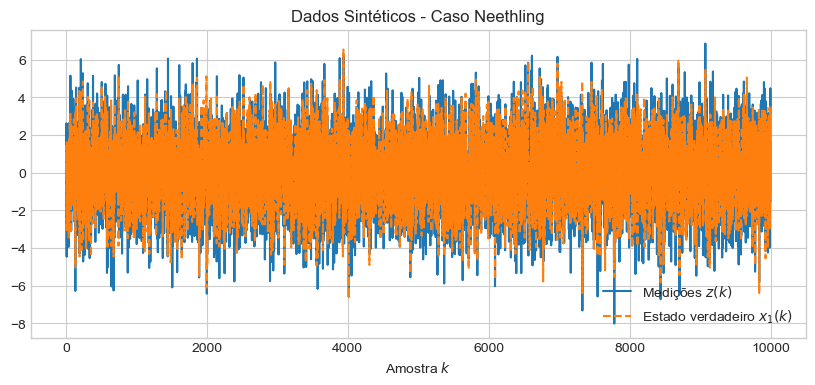

In [15]:
# Semente para reprodutibilidade
np.random.seed(42)

# Definição das matrizes do sistema
F = np.array([[0.8, 1.0],
              [-0.4, 0.0]])
H = np.array([[1.0, 0.0]])
Gamma = np.array([[1.0],
                  [1.0]])

# Covariâncias verdadeiras
Q_true = np.array([[0.5]])  # escalar pois nv = 1
R_true = np.array([[1]])

# Número de amostras
N = 10000
nx = F.shape[0]
nz = H.shape[0]
nv = Gamma.shape[1]

# Inicialização
x = np.zeros((N, nx))
z = np.zeros((N, nz))

#Verifica Identificabilidade do sistema
check_noise_identifiability(F, H, Gamma, verbose=True)

# Geração dos estados e medições
for k in range(1, N):
    v_k = np.random.multivariate_normal(np.zeros(nv), Q_true)
    w_k = np.random.multivariate_normal(np.zeros(nz), R_true)
    x[k] = F @ x[k-1] + (Gamma @ v_k).flatten()
    z[k] = H @ x[k] + w_k

# Visualização das medições
plt.figure(figsize=(10,4))
plt.plot(z, label='Medições $z(k)$')
plt.plot(x[:,0], '--', label='Estado verdadeiro $x_1(k)$')
plt.xlabel('Amostra $k$')
plt.legend()
plt.title('Dados Sintéticos - Caso Neethling')
plt.grid(True)
plt.show()

In [16]:
# Importa as funções do seu módulo (certifique-se de que estão definidas)
# from utils import *

# Parâmetros do algoritmo
M_lags = 10          # número de lags (≥ nx)
max_outer = 50       # iterações externas máximas
max_inner = 50       # iterações internas (Passo 3 e Passo 5)

# Executa o algoritmo adaptativo
W_est, R_est, Q_est, P_est, history = adaptive_kalman_filter(
    Z=z, F=F, H=H, Gamma=Gamma,
    M_lags=M_lags,
    max_outer=max_outer,
    max_inner=max_inner,
    method_R='R3',
    N_s = N,
    beta = 2,
    approx = True,
    verbose=False
)

print("\n=== RESULTADOS ===")
print("Ganho W estimado:\n", W_est)
print("R estimado:\n", R_est)
print("Q estimado:\n", Q_est)
print("P estimado:\n", P_est)


=== RESULTADOS ===
Ganho W estimado:
 [[0.63769143]
 [0.19666774]]
R estimado:
 [[0.96653705]]
Q estimado:
 [[0.63512255]]
P estimado:
 [[0.64494315 0.1258981 ]
 [0.1258981  0.68902666]]


In [17]:
# Ganho verdadeiro (calculado com DARE usando Q_true, R_true)
from scipy.linalg import solve_discrete_are
P_true = solve_discrete_are(F.T, H.T, Gamma @ Q_true @ Gamma.T, R_true)
S_true = H @ P_true @ H.T + R_true
W_true = P_true @ H.T @ np.linalg.inv(S_true)

print("=== COMPARAÇÃO ===")
print("W verdadeiro:\n", W_true)
print("W estimado:\n", W_est)
print("\nQ verdadeiro =", Q_true[0,0], "  Q estimado =", Q_est[0,0])
print("R verdadeiro =", R_true[0,0], "  R estimado =", R_est[0,0])

=== COMPARAÇÃO ===
W verdadeiro:
 [[0.61962611]
 [0.09961057]]
W estimado:
 [[0.63769143]
 [0.19666774]]

Q verdadeiro = 0.5   Q estimado = 0.6351225483724718
R verdadeiro = 1   R estimado = 0.9665370466412581


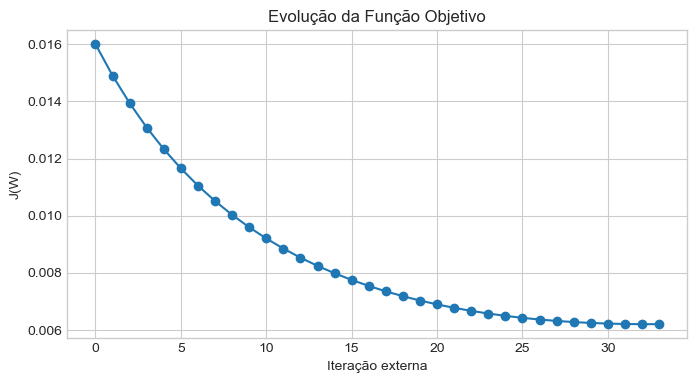

In [18]:
plt.figure(figsize=(8,4))
plt.plot(history['J'], 'o-')
plt.xlabel('Iteração externa')
plt.ylabel('J(W)')
plt.title('Evolução da Função Objetivo')
plt.grid(True)
plt.show()

# Gerando um script só para realizar essa análise

In [19]:
def run_adaptive_kalman_experiment(F, H, Gamma, Q_true, R_true, 
                                   N=10000, seed=42, 
                                   M_lags=10, max_outer=50, max_inner=50, 
                                   tol_J=1e-12, tol_W=1e-12, tol_grad=1e-12,
                                   c=0.01, c_max=0.2, grad_eps=1e-5, patience=5,
                                   beta=2.0, method_R='R3', diagonal_Q=False, 
                                   exp_name="Experimento"):
    """
    Método blindado com formatação de fontes específica para publicações.
    """
    print(f"\n{'='*30}\n INICIANDO: {exp_name}\n{'='*30}")
    
    # --- CRIAÇÃO AUTOMÁTICA DE PASTAS ---
    nome_pasta_seguro = exp_name.replace(" ", "_")
    pasta_destino = os.path.join("Figuras", "Algoritmo", nome_pasta_seguro)
    os.makedirs(pasta_destino, exist_ok=True)
    
    # 0. Geração dos Dados Interna
    np.random.seed(seed)
    nx, nz, nv = F.shape[0], H.shape[0], Gamma.shape[1]
    x, z = np.zeros((N, nx)), np.zeros((N, nz))

    for k in range(1, N):
        v_k = np.random.multivariate_normal(np.zeros(nv), Q_true)
        w_k = np.random.multivariate_normal(np.zeros(nz), R_true)
        x[k] = F @ x[k-1] + (Gamma @ v_k).flatten()
        z[k] = H @ x[k] + w_k
        
    print(f"Dados gerados com sucesso: N={N} amostras.")

    # Verifica Identificabilidade do sistema
    _, _, Imat = check_noise_identifiability(F, H, Gamma, verbose=True)
    
    # 1. Execução do Algoritmo Adaptativo
    print("\n--- Executando Algoritmo Adaptativo ---")
    W_est, R_est, Q_est, P_est, history = adaptive_kalman_filter(
        Z=z, F=F, H=H, Gamma=Gamma,
        M_lags=M_lags,
        max_outer=max_outer,
        max_inner=max_inner,
        tol_J=tol_J, tol_W=tol_W, tol_grad=tol_grad,
        c=c, c_max=c_max, grad_eps=grad_eps, patience=patience,
        method_R=method_R,
        N_s=N,
        beta=beta,
        approx=True,
        verbose=False
    )

    # 2. Cálculo do Ganho Verdadeiro (Ótimo via DARE)
    P_true = solve_discrete_are(F.T, H.T, Gamma @ Q_true @ Gamma.T, R_true)
    S_true = H @ P_true @ H.T + R_true
    W_true = P_true @ H.T @ np.linalg.inv(S_true)

    # 3. Exibição dos Resultados no Console
    print("\n" + "="*20 + " RESULTADOS FINAIS " + "="*20)
    best_J = min(history['J'])
    print(f"\nMelhor Custo J(W) encontrado: {best_J:.8f}")
    print("\n--- GANHO DE KALMAN (W) ---\n", np.round(W_est, 6))
    print("\n--- MATRIZ Q (Processo) ---\n", np.round(Q_est, 6))
    print("\n--- MATRIZ R (Medição) ---\n", np.round(R_est, 6))

    # 4. Evolução da Função Objetivo
    plt.figure(figsize=(10, 6))
    plt.plot(history['J'], 'o-', color='tab:blue', linewidth=2)
    
    # Ajuste de Fontes (Título 24, Labels 16)
    plt.title(f'Convergência $J(W)$ - {exp_name}', fontsize=24)
    plt.xlabel('Iteração Externa', fontsize=16)
    plt.ylabel('$J(W)$', fontsize=16)
    plt.grid(True, linestyle='--')

    caminho_J = os.path.join(pasta_destino, f"convergencia_J_{nome_pasta_seguro}.png")
    plt.savefig(caminho_J, dpi=300, bbox_inches='tight')
    plt.show()

# 5. Análise de NIS (Inovação Normalizada)
    nu_est, _ = generate_residuals(z, F, H, W_est)
    S_est_emp = (nu_est.T @ nu_est) / len(nu_est)
    S_inv = np.linalg.inv(S_est_emp)
    nis = np.array([n @ S_inv @ n for n in nu_est])
    
    # --- CÁLCULO DOS LIMITES QUI-QUADRADO (95% CONFIDENCE INTERVAL) ---
    alpha = 0.05
    # Limite inferior (2.5%) e Superior (97.5%) para df = nz
    limite_inferior = chi2.ppf(alpha / 2, df=nz)
    limite_superior = chi2.ppf(1 - alpha / 2, df=nz)
    
    # Validação quantitativa: quantos pontos realmente caíram no intervalo?
    dentro_limites = np.sum((nis >= limite_inferior) & (nis <= limite_superior))
    pct_dentro = (dentro_limites / len(nis)) * 100
    print(f"Teste NIS: {pct_dentro:.2f}% dos pontos estão dentro do intervalo de 95% de confiança.")

    plt.figure(figsize=(12, 5))
    
    # Plotagem principal dos pontos
    plt.plot(nis, 'b.', alpha=0.3, label='NIS Empírico')
    
    # Linhas de expectativa (Média)
    plt.axhline(y=nz, color='r', linestyle='--', label=f'Média Teórica ($n_z$={nz})')
    plt.axhline(y=np.mean(nis), color='g', linewidth=2, label=f'Média Real={np.mean(nis):.2f}')
    
    # Linhas dos limites de 95%
    plt.axhline(y=limite_superior, color='orange', linestyle='-', linewidth=2, label=f'Lim Sup 95% ({limite_superior:.2f})')
    plt.axhline(y=limite_inferior, color='orange', linestyle='-', linewidth=2, label=f'Lim Inf 95% ({limite_inferior:.2f})')
    
    # Ajuste visual das áreas fora dos limites para facilitar a interpretação
    plt.fill_between(range(len(nis)), limite_superior, max(nis)+5, color='red', alpha=0.05)
    plt.fill_between(range(len(nis)), 0, limite_inferior, color='red', alpha=0.05)

    # Ajuste de Fontes (Título 24, Labels 16)
    # Coloquei a porcentagem de acerto no próprio título para o seu artigo
    plt.title(f'Teste NIS - {exp_name} ({pct_dentro:.1f}% no intervalo)', fontsize=24)
    plt.xlabel('Amostra $k$', fontsize=16)
    plt.ylabel('Magnitude NIS', fontsize=16)
    
    # Posiciona a legenda fora do gráfico para não cobrir os dados
    plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Ajuste automático do layout devido à legenda externa
    plt.tight_layout()
    
    caminho_nis = os.path.join(pasta_destino, f"nis_{nome_pasta_seguro}.png")
    plt.savefig(caminho_nis, dpi=300, bbox_inches='tight')
    plt.show()

    # 6. Comparação das Covariâncias
    nu_opt, _ = generate_residuals(z, F, H, W_true) 
    S_opt_emp = (nu_opt.T @ nu_opt) / len(nu_opt)
    
    print("\n--- ANÁLISE DE COVARIÂNCIA DA INOVAÇÃO (S) ---")
    print("S Estimado Empírico:\n", np.round(S_est_emp, 6))
    print("S Ótimo Empírico:\n", np.round(S_opt_emp, 6))
    print("S Teórico (DARE):\n", np.round(S_true, 6))

    return W_est, R_est, Q_est, P_est, history, Imat

# Exemplos de Aplicação.

=== Exemplo 1: Sistema de Neethling ===

 INICIANDO: Caso Neethling
Dados gerados com sucesso: N=10000 amostras.
=== Análise de Identificabilidade das Matrizes de Ruído ===

Grau do polinômio mínimo (m): 2
Coeficientes a_i: [ 1.  -0.8  0.4]

Dimensão da matriz I: (3, 2)
Posto de I: 2

Parâmetros livres em Q (simétrica): 1
Parâmetros livres em R (simétrica): 1
Total de incógnitas: 2
Conclusão: Q e R SÃO identificáveis.

--- Considerando Q diagonal ---
Posto de I reduzida: 2
Total de incógnitas (Q diag + R sim): 2
Conclusão: Com Q diagonal, o sistema É identificável.

--- Executando Algoritmo Adaptativo ---

==================== RESULTADOS FINAIS ====================

Melhor Custo J(W) encontrado: 0.00619663

--- GANHO DE KALMAN (W) ---
 [[0.637691]
 [0.196668]]

--- MATRIZ Q (Processo) ---
 [[0.635123]]

--- MATRIZ R (Medição) ---
 [[0.966537]]


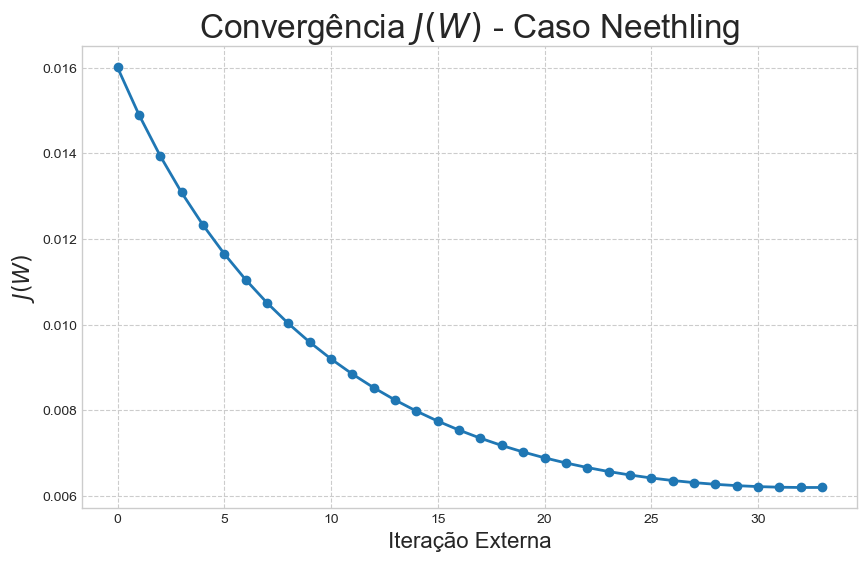

Teste NIS: 94.60% dos pontos estão dentro do intervalo de 95% de confiança.


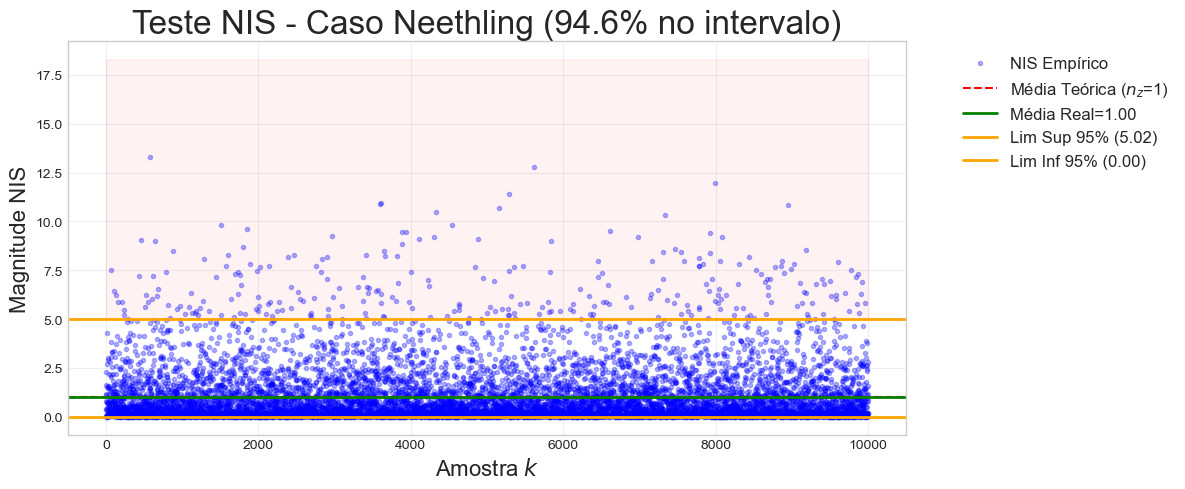


--- ANÁLISE DE COVARIÂNCIA DA INOVAÇÃO (S) ---
S Estimado Empírico:
 [[2.655159]]
S Ótimo Empírico:
 [[2.621748]]
S Teórico (DARE):
 [[2.628992]]


In [20]:
print("=== Exemplo 1: Sistema de Neethling ===")
# Definição das matrizes do sistema
F = np.array([[0.8, 1.0],
              [-0.4, 0.0]])
H = np.array([[1.0, 0.0]])
Gamma = np.array([[1.0],
                  [1.0]])

# Covariâncias verdadeiras
Q_true = np.array([[0.5]])  # escalar pois nv = 1
R_true = np.array([[1.0]])

# Executando tudo com 1 linha:
# 3. Chama o Método Encapsulado passando o "z"
W, R, Q, P, hist, Imat = run_adaptive_kalman_experiment(
    F=F, H=H, Gamma=Gamma, Q_true=Q_true, R_true=R_true, 
    N=10000, seed=42, diagonal_Q=True, exp_name="Caso Neethling"
)

=== Exemplo 2: Contraexemplo de Odelson ===

 INICIANDO: Caso Odelson
Dados gerados com sucesso: N=10000 amostras.
=== Análise de Identificabilidade das Matrizes de Ruído ===

Grau do polinômio mínimo (m): 2
Coeficientes a_i: [ 1.   -1.8   0.81]

Dimensão da matriz I: (12, 9)
Posto de I: 8

Parâmetros livres em Q (simétrica): 6
Parâmetros livres em R (simétrica): 3
Total de incógnitas: 9
Conclusão: Q e R NÃO são identificáveis (posto < número de incógnitas).

--- Considerando Q diagonal ---
Posto de I reduzida: 6
Total de incógnitas (Q diag + R sim): 6
Conclusão: Com Q diagonal, o sistema É identificável.

--- Executando Algoritmo Adaptativo ---

==================== RESULTADOS FINAIS ====================

Melhor Custo J(W) encontrado: 0.05996769

--- GANHO DE KALMAN (W) ---
 [[ 3.63451e-01  5.12100e-03]
 [ 8.04675e-01 -6.92100e-03]
 [-2.56000e-04  6.03255e-01]]

--- MATRIZ Q (Processo) ---
 [[ 0.206866  0.400121  0.005291]
 [ 0.400121  0.77587  -0.014754]
 [ 0.005291 -0.014754  0.3198

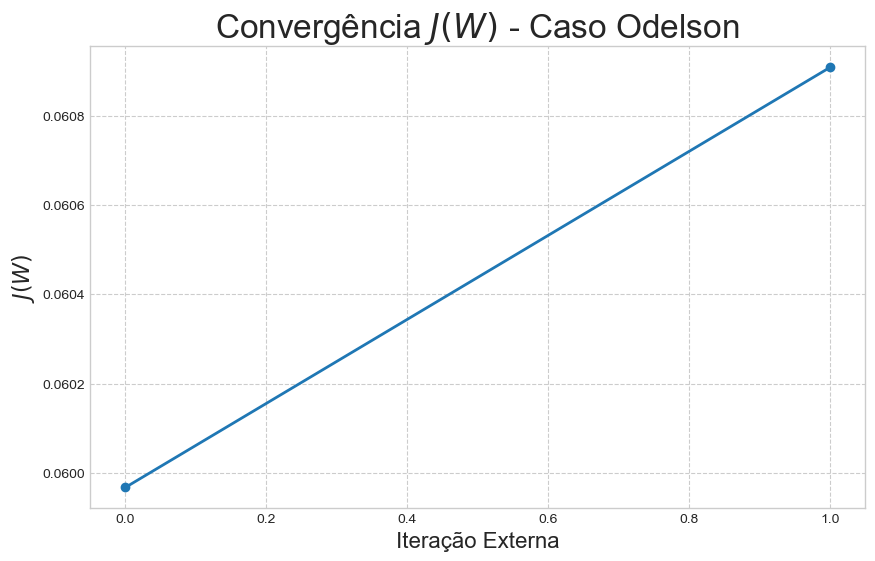

Teste NIS: 94.98% dos pontos estão dentro do intervalo de 95% de confiança.


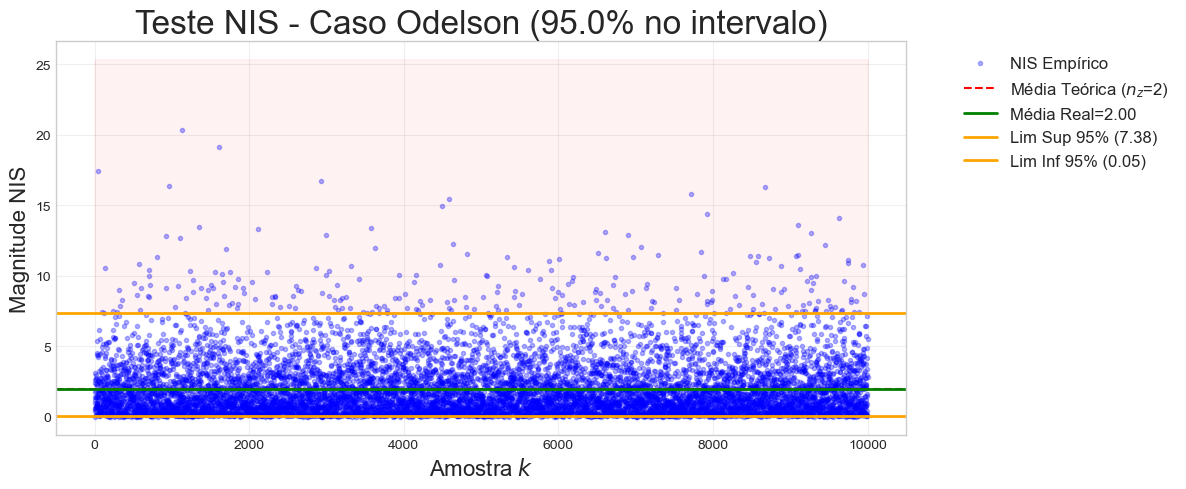


--- ANÁLISE DE COVARIÂNCIA DA INOVAÇÃO (S) ---
S Estimado Empírico:
 [[ 1.496566 -0.002382]
 [-0.002382  0.767365]]
S Ótimo Empírico:
 [[1.361838 0.003175]
 [0.003175 0.713979]]
S Teórico (DARE):
 [[ 1.362302 -0.      ]
 [-0.        0.726121]]


In [22]:
print("=== Exemplo 2: Contraexemplo de Odelson ===")
# Definição das matrizes do sistema
F = np.array([[0.9, 0.0, 0.0],
              [1.0, 0.9, 0.0],
              [0.0, 0.0, 0.9]])
H = np.array([[0.0, 1.0, 0.0],
              [0.0, 0.0, 1.0]])
Gamma = np.eye(3)

# Covariâncias verdadeiras (Assumidas Diagonais)
Q_true = np.diag([0.1, 0.2, 0.1])
R_true = np.diag([0.5, 0.5])

# Executando tudo com 1 linha:
# 3. Chama o Método Encapsulado passando o "z"
W, R, Q, P, hist, Imat = run_adaptive_kalman_experiment(
    F=F, H=H, Gamma=Gamma, Q_true=Q_true, R_true=R_true, 
    N=10000, seed=42, diagonal_Q=True, exp_name="Caso Odelson"
)


 INICIANDO: Caso Mehra
Dados gerados com sucesso: N=100000 amostras.
=== Análise de Identificabilidade das Matrizes de Ruído ===

Grau do polinômio mínimo (m): 5
Coeficientes a_i: [ 1.     -4.065   6.7114 -5.6117  2.3625 -0.3968]

Dimensão da matriz I: (24, 9)
Posto de I: 9

Parâmetros livres em Q (simétrica): 6
Parâmetros livres em R (simétrica): 3
Total de incógnitas: 9
Conclusão: Q e R SÃO identificáveis.

--- Considerando Q diagonal ---
Posto de I reduzida: 6
Total de incógnitas (Q diag + R sim): 6
Conclusão: Com Q diagonal, o sistema É identificável.

--- Executando Algoritmo Adaptativo ---

==================== RESULTADOS FINAIS ====================

Melhor Custo J(W) encontrado: 0.01140656

--- GANHO DE KALMAN (W) ---
 [[ 0.905454  0.72821 ]
 [-0.007959  0.237969]
 [-2.854962 -1.510619]
 [-0.005734  0.223118]
 [ 0.020671 -0.88646 ]]

--- MATRIZ Q (Processo) ---
 [[ 0.127577 -0.02702   0.02369 ]
 [-0.02702   0.188286 -0.230977]
 [ 0.02369  -0.230977  0.284071]]

--- MATRIZ R (Me

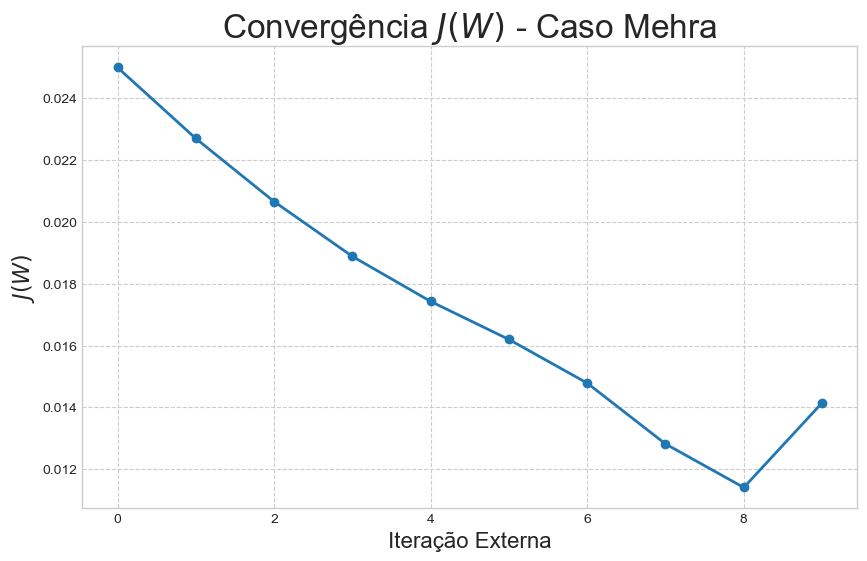

Teste NIS: 95.06% dos pontos estão dentro do intervalo de 95% de confiança.


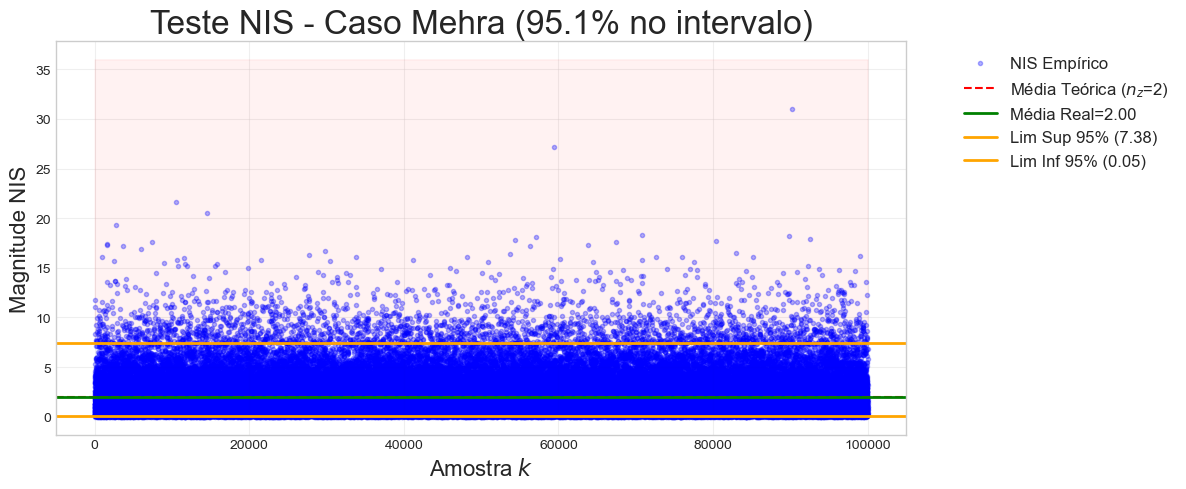


--- ANÁLISE DE COVARIÂNCIA DA INOVAÇÃO (S) ---
S Estimado Empírico:
 [[8.033352 0.048702]
 [0.048702 0.848873]]
S Ótimo Empírico:
 [[7.950646 0.066854]
 [0.066854 0.821664]]
S Teórico (DARE):
 [[7.978864 0.062983]
 [0.062983 0.822427]]


In [23]:
# Definição das matrizes do sistema
F = np.array([
    [0.75, -1.74, -0.3, 0.0, -0.15],
    [0.09,  0.91, -0.0015, 0.0, -0.008],
    [0.0,   0.0,   0.95, 0.0, 0.0],
    [0.0,   0.0,   0.0,  0.55, 0.0],
    [0.0,   0.0,   0.0,  0.0,  0.905]
])
H = np.array([
    [1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 1.0, 0.0, 1.0, 0.0]
])
Gamma = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [24.64, 0.0, 0.0],
    [0.0, 0.835, 0.0],
    [0.0, 0.0, 1.83]
])


# Q_true é 3x3 (devido às 3 colunas da matriz Gamma)
Q_true = np.array([
    [0.1, 0.0, 0.0],
    [0.0, 0.2, 0.0],
    [0.0, 0.0, 0.1]
])

# R_true é 2x2 (devido às 2 linhas da matriz H)
R_true = np.array([
    [0.5, 0.0],
    [0.0, 0.5]
])
# Executando tudo com 1 linha:
# 3. Chama o Método Encapsulado passando o "z"
W, R, Q, P, hist, Imat = run_adaptive_kalman_experiment(
    F=F, H=H, Gamma=Gamma, Q_true=Q_true, R_true=R_true, 
    N=100000, seed=42, diagonal_Q=True, exp_name="Caso Mehra"
)